# 实验1：定价模型的收敛性（对应论文图8 + 图9）

本notebook复现论文图8（数据数量 x 随迭代次数的收敛性）和图9（数据价格 p 随迭代次数的收敛性）。

实验设置：
- 5个数据所有者，随机从EUA数据集选取，具有不同的成本 c_i
- 使用 Algorithm 1 梯度迭代算法
- 预期结果：价格和数量在25次迭代内收敛

**数据源**：EUA Dataset (Melbourne CBD) — `/Experiment/data/eua-dataset/`

In [1]:
# ============ 可调参数 ============
N_OWNERS = 5                  # 数据所有者数量
SEED = 42                     # 随机种子
THETA_P = 10.0                # 空间距离阈值 (km)
THETA_T = 60.0                # 时间阈值 (min)
ALPHA = 0.5                   # 空间/时间权重
P_MAX = 10.0                  # 最高价格
X_MIN = 0.0                   # 最小购买量
X_MAX = 15.0                  # 最大购买量
MU = 0.05                     # 梯度步长
MAX_ITER = 250                # 最大迭代次数（真实数据需更多迭代收敛）
TOL = 1e-6                    # 收敛阈值

# 消费者位置（墨尔本中心附近）
CONSUMER_LAT = -37.81
CONSUMER_LON = 144.96
CONSUMER_TIME = 30.0          # 消费者请求时间 (min)

In [2]:
import sys
sys.path.insert(0, '../src')
import numpy as np
import matplotlib.pyplot as plt
from data_loader import load_eua_data, sample_owners, create_consumer
from quality_model import compute_quality
from stackelberg_model import run_stackelberg

# 加载数据
df = load_eua_data()
owners = sample_owners(df, n_owners=N_OWNERS, seed=SEED)
consumer = create_consumer(CONSUMER_LAT, CONSUMER_LON, CONSUMER_TIME)

# 计算质量因子
Q_raw = compute_quality(owners, consumer, THETA_P, THETA_T, ALPHA)
# 缩放Q值到论文实际使用的量级（论文图7中Q值为1.98~9.53，远超[0,1]）
Q = Q_raw * 10.0
c = owners['cost'].values

print('数据所有者质量 Q (缩放后):', Q)
print('数据所有者成本 c:', c)

数据所有者质量 Q (缩放后): [4.8411543  7.56817413 8.271249   4.93889606 8.45659558]
数据所有者成本 c: [1.50133661 0.75847981 0.78843353 0.56130292 0.75340259]


In [3]:
result = run_stackelberg(Q, c, p_max=P_MAX, x_min=X_MIN, x_max=X_MAX,
                         mu=MU, max_iter=MAX_ITER, tol=TOL)
print(f'收敛: {result["converged"]}, 迭代次数: {result["iterations"]}')

收敛: True, 迭代次数: 33


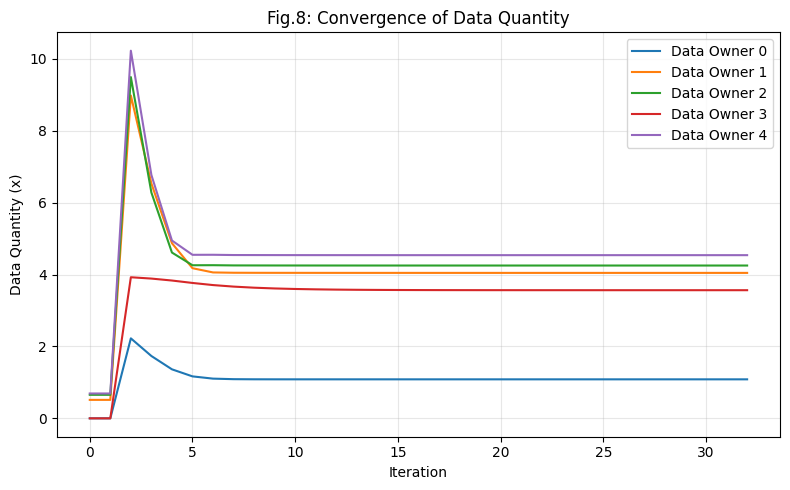

In [4]:
# 图8：数据数量收敛性
fig, ax = plt.subplots(figsize=(8, 5))
iterations = range(len(result['quantity_history']))
for i in range(N_OWNERS):
    ax.plot(iterations, result['quantity_history'][:, i], label=f'Data Owner {i}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Data Quantity (x)')
ax.set_title('Fig.8: Convergence of Data Quantity')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

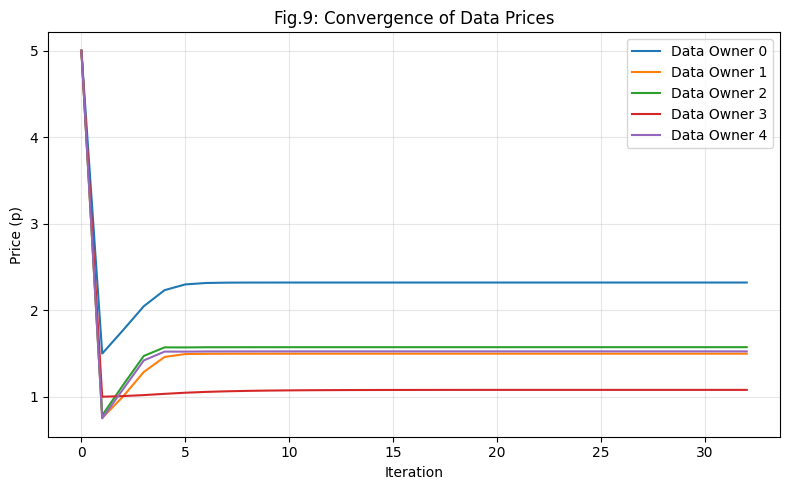

In [5]:
# 图9：数据价格收敛性
fig, ax = plt.subplots(figsize=(8, 5))
iterations = range(len(result['price_history']))
for i in range(N_OWNERS):
    ax.plot(iterations, result['price_history'][:, i], label=f'Data Owner {i}')
ax.set_xlabel('Iteration')
ax.set_ylabel('Price (p)')
ax.set_title('Fig.9: Convergence of Data Prices')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()